In [41]:
import torch

inputs = torch.tensor(
    [[0.72, 0.45, 0.31],
     [0.75, 0.20, 0.55],
     [0.60, 0.80, 0.90],
     [0.10, 0.25, 0.40],
     [0.85, 0.60, 0.70],
     [0.30, 0.15, 0.50],]
    )

# Corresponding Words

words = ["Dream", "big", "and", "work", "for", "it"]

In [42]:
# Calculate the magnitude of each vector
magnitudes = torch.norm(inputs, dim=1)

print("Magnitudes of vectors:")
for word, magnitude in zip(words, magnitudes):
    print(f"{word}: {magnitude.item():.4f}")

Magnitudes of vectors:
Dream: 0.9039
big: 0.9513
and: 1.3454
work: 0.4822
for: 1.2540
it: 0.6021


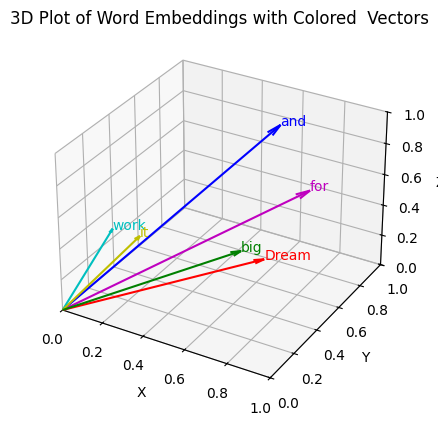

In [43]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# 3D plot with vectors from origin
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

colors = ["r", "g", "b", "c", "m", "y"]

for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    ax.quiver(0, 0, 0, x, y, z, color = color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])
plt.title("3D Plot of Word Embeddings with Colored  Vectors")
plt.show()

In [44]:
 # The dot product between the second input token and all words
query = inputs[1]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)

print(attn_scores_2)

tensor([0.8005, 0.9050, 1.1050, 0.3450, 1.1425, 0.5300])


In [45]:
attn_weight_2_tmpx = attn_scores_2 / attn_scores_2.sum()

print("Attention weights:", attn_weight_2_tmpx)
print("Sum:", attn_weight_2_tmpx.numpy().sum())

Attention weights: tensor([0.1658, 0.1874, 0.2289, 0.0715, 0.2366, 0.1098])
Sum: 1.0


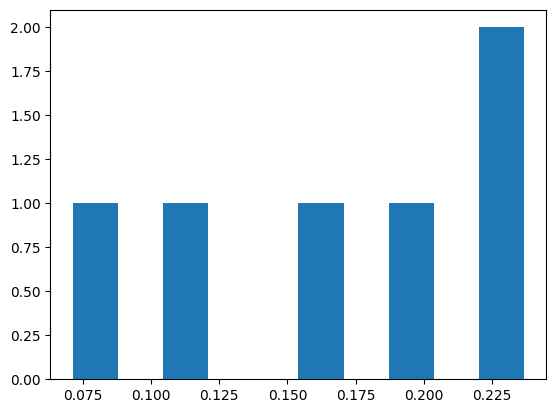

In [46]:
plt.hist(x=attn_weight_2_tmpx.numpy())
plt.show()

In [47]:
softmax = torch.nn.Softmax()

attn_weight_2_tmp = softmax(attn_scores_2)

print("Attention weights:", attn_weight_2_tmp)
print("Sum:", attn_weight_2_tmp.numpy().sum())


Attention weights: tensor([0.1595, 0.1770, 0.2162, 0.1011, 0.2245, 0.1217])
Sum: 0.99999994


/home/kilango-waziri/Documents/trial/venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


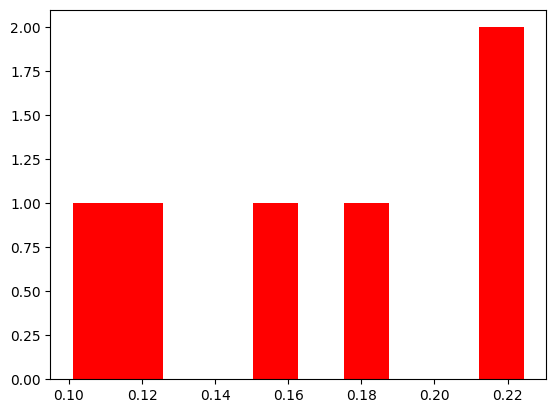

In [48]:
plt.hist(x=attn_weight_2_tmp, color='r', label="Softmax")
plt.show()

In [49]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.8170, 0.8005, 1.0710, 0.3085, 1.0990, 0.4385],
        [0.8005, 0.9050, 1.1050, 0.3450, 1.1425, 0.5300],
        [1.0710, 1.1050, 1.8100, 0.6200, 1.6200, 0.7500],
        [0.3085, 0.3450, 0.6200, 0.2325, 0.5150, 0.2675],
        [1.0990, 1.1425, 1.6200, 0.5150, 1.5725, 0.6950],
        [0.4385, 0.5300, 0.7500, 0.2675, 0.6950, 0.3625]])


In [50]:
all_context_vector = attn_weight_2_tmp @ inputs
print(all_context_vector)

tensor([0.6148, 0.4584, 0.5998])


In [51]:
inputs = torch.cat((inputs, all_context_vector.unsqueeze(0)), dim=0)

In [52]:
words.append("all_context_vector")

In [53]:
print(inputs)

tensor([[0.7200, 0.4500, 0.3100],
        [0.7500, 0.2000, 0.5500],
        [0.6000, 0.8000, 0.9000],
        [0.1000, 0.2500, 0.4000],
        [0.8500, 0.6000, 0.7000],
        [0.3000, 0.1500, 0.5000],
        [0.6148, 0.4584, 0.5998]])


In [54]:
print(words[0])

Dream


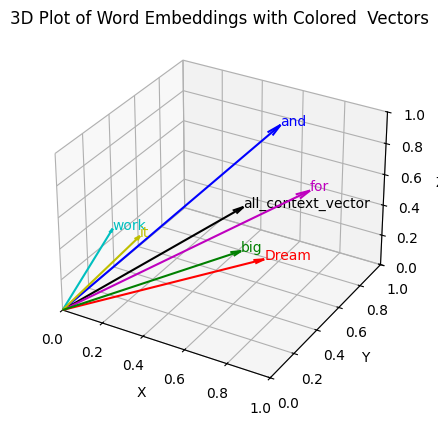

In [56]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# 3D plot with vectors from origin
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

colors = ["r", "g", "b", "c", "m", "y", "black"]

for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    ax.quiver(0, 0, 0, x, y, z, color = color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])
plt.title("3D Plot of Word Embeddings with Colored  Vectors")
plt.show()